# Feature Selection и PCA — простыми словами

Это **упрощённая** версия урока про отбор признаков и PCA.

**Что делаем:** учимся **уменьшать число колонок** в таблице, чтобы модель работала проще, быстрее и часто даже лучше.

---

## Аналогия на каждый день

Представьте, что вы угадываете: **хорошая погода на пикник или нет**.

У вас 100 «подсказок»:
- полезные: температура, облачность, ветер;
- бесполезные: цвет футболки соседа, номер дома напротив (это **шум**).

**Feature Selection** — выкинуть ненужные подсказки, оставить полезные.  
**PCA** — не выкидывать, а **сжать** много подсказок в несколько новых «сводных».

---

## План

1. Подготовка данных  
2. Baseline — «как есть, на всех колонках»  
3. SelectKBest — быстрый отбор  
4. RFE — отбор с учётом модели  
5. PCA — сжатие в новые оси  
6. Итог: что выбрать


## 0. Что понадобится из Python

Ниже — библиотеки. Не обязательно понимать каждую строку: это «инструменты с полки».


In [81]:
# Подключаем инструменты
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import SelectKBest, f_classif, RFE
from sklearn.decomposition import PCA
from sklearn.metrics import roc_auc_score, f1_score
from time import perf_counter

# Чтобы случайные числа повторялись одинаково при каждом запуске
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Готово: библиотеки загружены")


Готово: библиотеки загружены


## 1. Подготовка данных

### Что такое «признаки» и «цель»

| Слово | Простыми словами | В нашей задаче |
|--------|------------------|----------------|
| **Признак (feature)** | колонка-подсказка | размер клеток, шум и т.д. |
| **Цель (target, y)** | что предсказываем | 0 = злокачественная, 1 = доброкачественная |
| **Объект (строка)** | один пример | один пациент / один снимок |

Мы используем учебный набор **Breast Cancer** из sklearn:  
~569 строк, 30 «настоящих» числовых признаков.

### Зачем добавляем шум

В реальной жизни часто много лишних колонок.  
Мы **сами добавим 70 случайных** колонок `noise_00`, `noise_01`, …  
чтобы методы отбора могли показать: «настоящие» признаки важнее мусора.

### Зачем делить данные на 3 части

| Часть | Доля (примерно) | Зачем |
|--------|-----------------|--------|
| **train** | 60% | учим модель |
| **valid** | 20% | подбираем «сколько признаков оставить» |
| **test** | 20% | финальная честная проверка |

**Аналогия:** train — учебник, valid — пробник, test — экзамен (на экзамен не подглядываем при подготовке).


In [82]:
# --- 1.1. Загружаем данные ---
data = load_breast_cancer(as_frame=True)
X_base = data.data.copy()   # таблица признаков (колонки-подсказки)
y = data.target.copy()      # ответы 0/1

print("Строк и колонок в исходных данных:", X_base.shape)
print("Пример названий признаков:", list(X_base.columns[:5]), "...")
print("Классы (сколько раз встречается 0 и 1):")
print(y.value_counts().sort_index())


Строк и колонок в исходных данных: (569, 30)
Пример названий признаков: ['mean radius', 'mean texture', 'mean perimeter', 'mean area', 'mean smoothness'] ...
Классы (сколько раз встречается 0 и 1):
target
0    212
1    357
Name: count, dtype: int64


In [83]:
# --- 1.2. Добавляем 70 шумовых колонок ---
# Это просто случайные числа: они НЕ связаны с болезнью.
n_noise = 70
rng = np.random.default_rng(RANDOM_STATE)

noise = pd.DataFrame(
    rng.normal(size=(len(X_base), n_noise)),  # нормальный шум
    columns=[f"noise_{i:02d}" for i in range(n_noise)],
    index=X_base.index
)

# Склеиваем: настоящие + шум
X = pd.concat([X_base, noise], axis=1)

print("Было колонок:", X_base.shape[1])
print("Стало колонок:", X.shape[1], "(30 полезных + 70 шума)")
print("Первые шумовые колонки:", list(X.columns[-3:]))


Было колонок: 30
Стало колонок: 100 (30 полезных + 70 шума)
Первые шумовые колонки: ['noise_67', 'noise_68', 'noise_69']


In [84]:
# --- 1.3. Делим на train / valid / test ---
# Шаг A: 80% "dev" (для обучения+подбора) и 20% test (экзамен)
X_dev, X_test, y_dev, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,              # сохраняем долю классов 0/1
    random_state=RANDOM_STATE
)

# Шаг B: dev делим на train 75% и valid 25%
# Итого от всего датасета: train 60%, valid 20%, test 20%
X_train, X_valid, y_train, y_valid = train_test_split(
    X_dev, y_dev,
    test_size=0.25,
    stratify=y_dev,
    random_state=RANDOM_STATE
)

print("Train:", X_train.shape, "— учимся здесь")
print("Valid:", X_valid.shape, "— подбираем параметры")
print("Test :", X_test.shape, "— финальная проверка")


Train: (341, 100) — учимся здесь
Valid: (114, 100) — подбираем параметры
Test : (114, 100) — финальная проверка


## 2. Baseline — точка отсчёта

**Baseline** = модель «на всех колонках, как есть».

Дальше любой метод (SelectKBest, RFE, PCA) мы сравниваем с baseline:

> «Стало лучше / хуже / почти так же, но с меньшим числом колонок?»

### Как устроена простая модель здесь

1. **StandardScaler** — приводит числа к одному масштабу  
   (чтобы «возраст 50» и «доход 50000» не спорили из‑за единиц измерения).
2. **LogisticRegression** — линейный классификатор «да/нет» (0/1).  
   Достаточно думать: *модель учится весам признаков и выдаёт вероятность класса*.

### Метрики (очень коротко)

| Метрика | Смысл одной фразой |
|---------|---------------------|
| **ROC-AUC** | насколько хорошо модель **ранжирует** «скорее 1» выше, чем «скорее 0» (1.0 = идеально, 0.5 = как монетка) |
| **F1** | баланс точности и полноты при жёстком решении 0/1 |
| **fit_sec** | сколько секунд училась модель |

### Мини-пример: «падение качества в процентах»

Если baseline ROC-AUC = **0.98**, а новая модель = **0.96**:

$$
\text{падение} = \frac{0.98 - 0.96}{0.98} \times 100\% \approx 2.04\%
$$

Правило в уроке: хотим падение **меньше 2%** (или даже рост качества).


In [85]:
# --- 2.1. Функции оценки (будем переиспользовать) ---

def fit_and_eval(pipe, X_fit, y_fit, X_eval, y_eval):
    """Обучить pipeline на обучающей выборке и оценить качество на проверочной.

    Параметры:
        pipe: Pipeline с шагами масштабирования, отбора признаков и модели.
        X_fit, y_fit: данные для обучения.
        X_eval, y_eval: данные для оценки качества.

    Возвращает:
        dict: метрики roc_auc, f1 и время обучения fit_sec.
    """
    t0 = perf_counter()
    pipe.fit(X_fit, y_fit)                 # обучение
    fit_sec = perf_counter() - t0

    y_pred = pipe.predict(X_eval)          # жёсткий ответ 0/1
    y_prob = pipe.predict_proba(X_eval)[:, 1]  # вероятность класса 1

    return {
        "roc_auc": roc_auc_score(y_eval, y_prob),
        "f1": f1_score(y_eval, y_pred),
        "fit_sec": fit_sec
    }


def drop_pct(new_metric, base_metric):
    """Посчитать падение метрики относительно baseline в процентах.

    Формула:
        (base_metric - new_metric) / base_metric * 100

    Возвращает:
        Положительное число — ухудшение качества,
        отрицательное число — улучшение качества
        по сравнению с baseline.
    """
    return (base_metric - new_metric) / base_metric * 100


# Мини-проверка формулы руками.
# Числа 0.96 / 0.99 / 0.98 здесь НЕ из нашей модели — это выдуманный пример,
# чтобы увидеть, как считается процент: new=0.96 vs base=0.98 → падение,
# new=0.99 vs base=0.98 → улучшение (отрицательный %).
# Реальные ROC-AUC появятся ниже, после обучения baseline.
print("Пример drop_pct(0.96, 0.98) =", round(drop_pct(0.96, 0.98), 2), "%")
print("Пример drop_pct(0.99, 0.98) =", round(drop_pct(0.99, 0.98), 2), "%  (отрицательное = лучше)")


Пример drop_pct(0.96, 0.98) = 2.04 %
Пример drop_pct(0.99, 0.98) = -1.02 %  (отрицательное = лучше)


In [86]:
# --- 2.2. Baseline: все признаки ---
baseline_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(
        max_iter=3000,
        solver="liblinear",
        random_state=RANDOM_STATE
    ))
])

baseline_valid = fit_and_eval(baseline_pipe, X_train, y_train, X_valid, y_valid)

print("Baseline на validation (все", X_train.shape[1], "признака):")
display(pd.DataFrame([baseline_valid]).round(4))


Baseline на validation (все 100 признака):


,roc_auc,f1,fit_sec
0,0.9859,0.979,0.0167


## 3. SelectKBest — «оставить top‑k самых связанных с ответом»

### Идея одной фразой

Для **каждой колонки отдельно** смотрим: «насколько она связана с y?»  
Оставляем **k** лучших.

Это **filter**-метод: быстрый, модель внутри почти не участвует (только критерий `f_classif`).

### Мини-пример «как ранжируют»

Представим 3 признака и ответы (упрощённо):

| человек | температура | шум | класс (пикник) |
|---------|-------------|-----|----------------|
| A | 25 | 0.1 | 1 |
| B | 5 | 0.9 | 0 |
| C | 22 | -0.2 | 1 |

«Температура» явно помогает угадать класс, «шум» — нет.  
SelectKBest поставит температуру выше.

### Что делаем в коде (кратко)

1. Перебираем разные **k** (5, 10, 20, …).  
2. Для каждого k учим модель и смотрим ROC-AUC на valid.  
3. Берём **самое маленькое k**, где падение AUC < 2% относительно baseline.

Подробный разбор шагов — в markdown **перед** каждой кодовой ячейкой ниже (3.1 и 3.2).


### Что делаем в коде (ячейка 3.1 — перебор k)

Здесь мы **ещё не выбираем** лучшее k. Мы просто пробуем много вариантов и записываем результаты в таблицу.

1. **Задаём список `k_grid`**  
   Например: 5, 8, 10, …, 100.  
   Каждое число = «сколько лучших признаков оставить».

2. **Для каждого k собираем конвейер (Pipeline)**  
   - `SelectKBest(..., k=k)` — оставляет только top‑k колонок по связи с ответом `y`;  
   - `StandardScaler` — приводит числа к одному масштабу;  
   - `LogisticRegression` — учится предсказывать класс 0/1.

3. **Учим на train, оцениваем на valid**  
   Функция `fit_and_eval(...)` возвращает ROC-AUC, F1 и время обучения.  
   Valid — «пробник»: на нём подбираем k, а не test (экзамен).

4. **Кладём результат в список `rows`**  
   Одна строка таблицы = одно значение k и его метрики.

5. **Считаем столбец `auc_drop_pct_vs_baseline`**  
   Сравниваем ROC-AUC при этом k с baseline (модель на всех признаках):  
   \((\text{baseline} - \text{новый}) / \text{baseline} \times 100\%\).  
   Хотим, чтобы число было **меньше 2** (просадка меньше 2%), лучше — отрицательное (качество выросло).

6. **Смотрим таблицу**  
   Чем меньше k при хорошем AUC — тем компактнее модель.  
   Выбор «какое k взять» — в **следующей** ячейке.


In [87]:
# --- 3.1. Перебор k ---
k_grid = [5, 8, 10, 12, 15, 20, 25, 30, 40, 50, 70, 100]

rows = []
for k in k_grid:
    pipe = Pipeline([
        # 1) оставить k лучших признаков по f_classif
        ("select", SelectKBest(score_func=f_classif, k=k)),
        # 2) масштабировать
        ("scaler", StandardScaler()),
        # 3) классифицировать
        ("clf", LogisticRegression(
            max_iter=3000, solver="liblinear", random_state=RANDOM_STATE
        ))
    ])
    m = fit_and_eval(pipe, X_train, y_train, X_valid, y_valid)
    rows.append({"k": k, **m})

selectk_results = pd.DataFrame(rows).sort_values("k").reset_index(drop=True)

# Считаем падение относительно baseline (как в формуле выше)
selectk_results["auc_drop_pct_vs_baseline"] = drop_pct(
    selectk_results["roc_auc"],
    baseline_valid["roc_auc"]
)

print("Чем меньше k — тем компактнее модель.")
print("Смотрим столбец auc_drop_pct_vs_baseline: хотим < 2.")
display(selectk_results.round(4))


Чем меньше k — тем компактнее модель.
Смотрим столбец auc_drop_pct_vs_baseline: хотим < 2.


,k,roc_auc,f1,fit_sec,auc_drop_pct_vs_baseline
0,5,0.9774,0.9452,0.0067,0.8638
1,8,0.9764,0.9583,0.0029,0.9635
2,10,0.9781,0.9510,0.0028,0.7973
3,12,0.9777,0.9510,0.0033,0.8306
4,15,0.9895,0.9437,0.0027,-0.3654
5,20,0.9977,0.9861,0.0030,-1.1960
6,25,0.9984,0.9930,0.0030,-1.2625
7,30,0.9964,0.9859,0.0029,-1.0631
8,40,0.9915,0.9645,0.0033,-0.5648
9,50,0.9921,0.9650,0.0032,-0.6312


### Что делаем в коде (ячейка 3.2 — выбираем best_k и рисуем график)

Теперь по таблице из прошлой ячейки **выбираем одно k** и смотрим картинку «качество vs число признаков».

1. **Отфильтровываем допустимые k**  
   `ok = ... auc_drop_pct_vs_baseline < 2`  
   Оставляем только те k, где падение ROC-AUC относительно baseline **меньше 2%**.

2. **Берём самое маленькое такое k**  
   `best_k = ok["k"].min()`  
   Логика: среди вариантов, которые почти не хуже baseline, выбираем **самый компактный** (меньше признаков = проще модель).

3. **Запасной план**  
   Если ни одно k не уложилось в 2%, берём k с **максимальным** ROC-AUC на valid  
   (не идеально по правилу «меньше 2%», но лучшее из того, что есть).

4. **Строим график**  
   - по оси X — k (сколько признаков оставили);  
   - по оси Y — ROC-AUC на valid;  
   - пунктирная линия — baseline (все признаки).  

   **Как читать:** если точки SelectKBest близки к пунктиру (или выше), значит малое k почти не портит качество.  
   `best_k` — точка, которую мы дальше используем на test.


Выбрали best_k = 5


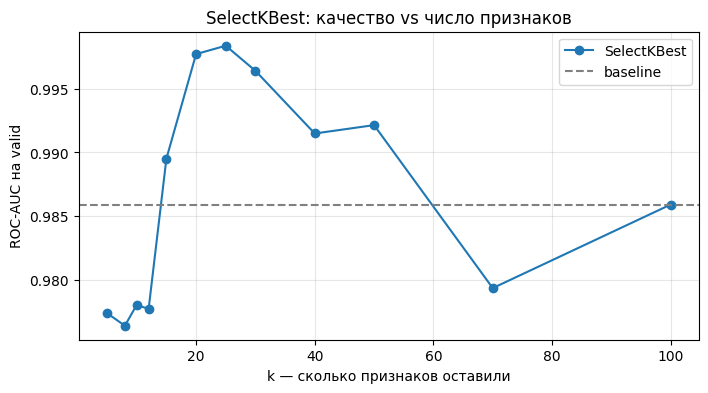

In [88]:
# --- 3.2. Выбираем best_k и рисуем график ---
ok = selectk_results[selectk_results["auc_drop_pct_vs_baseline"] < 2]

if len(ok) > 0:
    best_k = int(ok["k"].min())   # самое маленькое k с допустимым качеством
else:
    best_k = int(selectk_results.loc[selectk_results["roc_auc"].idxmax(), "k"])

print("Выбрали best_k =", best_k)

plt.figure(figsize=(8, 4))
plt.plot(selectk_results["k"], selectk_results["roc_auc"], marker="o", label="SelectKBest")
plt.axhline(baseline_valid["roc_auc"], linestyle="--", color="gray", label="baseline")
plt.xlabel("k — сколько признаков оставили")
plt.ylabel("ROC-AUC на valid")
plt.title("SelectKBest: качество vs число признаков")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


In [89]:
# --- 3.3. Финал SelectKBest: учим на train+valid, проверяем на test ---
# dev = train + valid (больше данных перед экзаменом)

baseline_final = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=3000, solver="liblinear", random_state=RANDOM_STATE))
])
baseline_test = fit_and_eval(baseline_final, X_dev, y_dev, X_test, y_test)

selectk_final = Pipeline([
    ("select", SelectKBest(score_func=f_classif, k=best_k)),
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=3000, solver="liblinear", random_state=RANDOM_STATE))
])
selectk_test = fit_and_eval(selectk_final, X_dev, y_dev, X_test, y_test)

# Какие именно колонки выбрал SelectKBest?
selectk_final.fit(X_dev, y_dev)
mask = selectk_final.named_steps["select"].get_support()  # True/False по каждой колонке
selected_k_names = X.columns[mask].tolist()

selectk_drop_test = drop_pct(selectk_test["roc_auc"], baseline_test["roc_auc"])

print("Отобранные признаки (SelectKBest):")
print(selected_k_names)
print()
print("Падение ROC-AUC на test vs baseline, %:", round(selectk_drop_test, 4))
print("(отрицательное число = качество выросло)")

display(pd.DataFrame([
    {"method": "baseline (все признаки)", **baseline_test, "n_features": X.shape[1]},
    {"method": f"SelectKBest k={best_k}", **selectk_test, "n_features": best_k},
]).round(4))


Отобранные признаки (SelectKBest):
['mean perimeter', 'mean concave points', 'worst radius', 'worst perimeter', 'worst concave points']

Падение ROC-AUC на test vs baseline, %: -1.2838
(отрицательное число = качество выросло)


,method,roc_auc,f1,fit_sec,n_features
0,baseline (все признаки),0.9788,0.9577,0.0102,100
1,SelectKBest k=5,0.9914,0.9429,0.0028,5


## 4. RFE — «модель сама выкидывает лишнее по кругу»

### Идея одной фразой

**RFE** (Recursive Feature Elimination):

1. Обучить модель на всех признаках.  
2. Выкинуть самые «слабые» (маленький вклад).  
3. Повторять, пока не останется нужное число признаков.

Это **wrapper**-метод: медленнее SelectKBest, но смотрит на признаки **вместе с моделью**.

### Мини-схема

```
100 признаков → выкинули 5 слабых → 95
             → выкинули 5 слабых → 90
             → ...
             → осталось n лучших
```

В коде `step=5` как раз значит «удалять по 5 за раз».

### Чем отличается от SelectKBest

| | SelectKBest | RFE |
|--|-------------|-----|
| Смотрит признаки | по одному | в связке с моделью |
| Скорость | быстро | медленнее |
| Набор признаков | может отличаться | часто «другой» набор |

Подробный разбор кода — в markdown **перед** ячейками 4.1 (перебор n) и 4.2 (выбор best_n_rfe).


### Что делаем в коде (ячейка 4.1 — перебор n для RFE)

Здесь мы **ещё не выбираем** финальное число признаков.  
Мы пробуем разные `n` («оставить 5 / 10 / 20 … колонок») и для **каждого** n:

1. запускаем RFE (он сам решает, *какие* n колонок оставить);  
2. учим классификатор на отобранных колонках;  
3. записываем качество на valid в таблицу.

Выбор «какое n лучше» — в **следующей** ячейке (`best_n_rfe`).

---

#### 1. Сетка `n_grid`

```python
n_grid = [5, 8, 10, 12, 15, 20, 25, 30]
```

- Это кандидаты: «сколько признаков RFE должен оставить».  
- Сетка **короче**, чем в полном скринкасте (там были и 40, 50…) — так быстрее и проще смотреть таблицу.  
- Аналог `k_grid` у SelectKBest, только параметр называется `n_features_to_select`.

---

#### 2. Цикл `for n in n_grid`

Для **каждого** n собираем свой Pipeline и один раз обучаем/оцениваем его.  
Результат одной итерации — одна строка будущей таблицы `rfe_results`.

---

#### 3. Что внутри Pipeline (по шагам)

```text
X_train  →  StandardScaler  →  RFE  →  LogisticRegression  →  предсказания
```

| Шаг | Имя в коде | Простыми словами |
|-----|------------|------------------|
| 1 | `scaler` | Привести все колонки к одному масштабу (иначе «большие» числа перетянут на себя важность). |
| 2 | `rfe` | **Отбор признаков:** модель-оценщик учится, выкидывает слабые колонки, снова учится… пока не останется ровно `n`. |
| 3 | `clf` | **Финальный классификатор:** учится уже только на тех колонках, которые оставил RFE, и предсказывает 0/1. |

**Важно:** внутри RFE стоит свой `LogisticRegression` (`estimator=...`) — это «судья важности» признаков.  
Снаружи после RFE — **другой** `LogisticRegression` (`clf`) — это уже «рабочая» модель для метрик.  
Оба одного типа, но роли разные: *отобрать* vs *предсказать*.

---

#### 4. Как работает RFE при фиксированном n (внутри одного прогона)

Допустим, колонок 100, `n_features_to_select=10`, `step=5`:

```text
старт: 100 признаков
  → обучили estimator, выкинули 5 самых слабых → 95
  → снова обучили, выкинули 5 → 90
  → … повторяем …
  → осталось 10 признаков  ← стоп
```

- **`n_features_to_select=n`** — цель: сколько колонок оставить в конце.  
- **`step=5`** — за один «круг» удаляем до 5 слабых (ускоряет; если `step=1`, удаляли бы по одному — медленнее).  
- «Слабость» для логистической регрессии обычно смотрят по **величине коэффициентов** (маленький вес → признак слабее).

Это **wrapper**: признак оценивается не «в одиночку» (как в SelectKBest), а **в контексте модели**.

---

#### 5. Обучение и метрики

```python
m = fit_and_eval(pipe, X_train, y_train, X_valid, y_valid)
```

- **Учимся** на `X_train`, `y_train` (включая отбор RFE — он тоже смотрит только train).  
- **Оцениваем** на `X_valid`, `y_valid`: ROC-AUC, F1, время.  
- Test здесь **не трогаем** — иначе «подглядим» в экзамен при подборе n.

```python
rows.append({"n_features": n, **m})
```

В список кладём: какое было n + метрики этого прогона.

---

#### 6. Таблица и сравнение с baseline

```python
rfe_results = pd.DataFrame(rows)...
rfe_results["auc_drop_pct_vs_baseline"] = drop_pct(...)
```

- Собираем все строки в DataFrame, сортируем по `n_features`.  
- Столбец **`auc_drop_pct_vs_baseline`**: на сколько % ROC-AUC хуже (или лучше), чем у baseline на всех признаках.  
  - **меньше 2** — вариант «приемлемый» по правилу урока;  
  - **отрицательное** — даже лучше baseline (часто так бывает, когда уходит шум).

`display(rfe_results.round(4))` — смотрим таблицу глазами: при каком n качество уже хорошее, а признаков ещё мало.

---

#### Мини-схема «что получится на выходе»

| n_features | roc_auc | f1 | fit_sec | auc_drop_pct_vs_baseline |
|------------|---------|-----|---------|--------------------------|
| 5 | … | … | … | … |
| 10 | … | … | … | … |
| … | … | … | … | … |

Дальше (ячейка 4.2) из этой таблицы выберем **`best_n_rfe`** — обычно минимальное n, где падение AUC меньше 2%.


In [90]:
# --- 4.1. Перебор числа признаков для RFE ---
# (сетка чуть короче, чем в полном скринкасте — так быстрее и понятнее)
n_grid = [5, 8, 10, 12, 15, 20, 25, 30]

rows = []
for n in n_grid:
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("rfe", RFE(
            estimator=LogisticRegression(
                max_iter=3000, solver="liblinear", random_state=RANDOM_STATE
            ),
            n_features_to_select=n,  # сколько оставить
            step=5                    # сколько выкидывать за шаг
        )),
        ("clf", LogisticRegression(
            max_iter=3000, solver="liblinear", random_state=RANDOM_STATE
        ))
    ])
    m = fit_and_eval(pipe, X_train, y_train, X_valid, y_valid)
    rows.append({"n_features": n, **m})

rfe_results = pd.DataFrame(rows).sort_values("n_features").reset_index(drop=True)
rfe_results["auc_drop_pct_vs_baseline"] = drop_pct(
    rfe_results["roc_auc"], baseline_valid["roc_auc"]
)

display(rfe_results.round(4))


,n_features,roc_auc,f1,fit_sec,auc_drop_pct_vs_baseline
0,5,0.9830,0.9722,0.0459,0.2990
1,8,0.9921,0.9726,0.0402,-0.6312
2,10,0.9934,0.9583,0.0395,-0.7641
3,12,0.9912,0.9437,0.0385,-0.5316
4,15,0.9872,0.9510,0.0381,-0.1329
5,20,0.9820,0.9577,0.0358,0.3987
6,25,0.9836,0.9517,0.0356,0.2326
7,30,0.9862,0.9577,0.0354,-0.0332


### Что делаем в коде (ячейка 4.2 — выбираем best_n_rfe для RFE)

В **прошлой** ячейке RFE уже прогнал несколько значений `n` (сколько признаков оставить) и заполнил таблицу `rfe_results`.  
Сейчас по этой таблице выбираем **одно** число `best_n_rfe` — «сколько признаков оставит RFE в финальной модели».

Логика **такая же по смыслу**, как у SelectKBest с `best_k`, только параметр называется `n_features`, а не `k`.

---

#### 1. Отбираем «хорошие» варианты RFE

```python
ok_rfe = rfe_results[rfe_results["auc_drop_pct_vs_baseline"] < 2]
```

- Берём только те строки, где ROC-AUC на valid **почти не хуже** baseline (падение меньше 2%).  
- Если в `ok_rfe` есть строки — значит, RFE с таким числом признаков **укладывается в правило качества**.  
- Если таблица пустая — ни один `n` не прошёл порог 2% (редко, но бывает).

**Пример (выдуманные числа):**

| n_features | roc_auc | auc_drop_pct_vs_baseline |
|------------|---------|--------------------------|
| 5 | 0.97 | 1.5 |
| 10 | 0.98 | 0.5 |
| 20 | 0.96 | 2.5 |

В `ok_rfe` попадут только **5** и **10** (падение меньше 2%). Строка с 20 — нет.

---

#### 2. Главное правило: самое маленькое n среди хороших

```python
best_n_rfe = int(ok_rfe["n_features"].min())
```

- Среди вариантов, которые **не портят** качество, берём **минимальное** число признаков.  
- Зачем: RFE уже умеет отбрасывать слабые колонки; нам нужна **самая компактная** модель, которая ещё «держит» AUC.  
- В примере выше: из 5 и 10 выбираем **`best_n_rfe = 5`**.

Именно это `best_n_rfe` потом пойдёт в `n_features_to_select=...` в финальном Pipeline на test.

---

#### Почему часто выбирают 5, а не 10? (даже если у 10 ROC-AUC выше)

**Вы правы:** на valid у `n=10` ROC-AUC **часто лучше**, чем у `n=5`.  
Но код **не** ищет «максимальный ROC-AUC». Он ищет другое:

> «Среди всех n, где падение AUC относительно baseline **меньше 2%**, взять **наименьшее** n.»

| Вопрос | Ответ |
|--------|--------|
| Кто «победил» по чистому качеству? | Часто **10** (выше ROC-AUC) |
| Кого выбирает **этот** код? | **5**, если оба прошли порог «падение меньше 2%» |
| Это ошибка? | **Нет** — это осознанное правило «компактность при допустимом качестве» |
| Когда взяли бы 10? | Если 5 **не** в `ok_rfe` (просадка ≥ 2%), а 10 — в `ok_rfe`; или если меняем правило на `idxmax()` по AUC |

**Аналогия:**  
«Нужна квартира **не хуже чем на 2%** от идеала, и среди таких — **самая дешёвая**».  
10-комнатная может быть чуть «лучше», но 5-комнатная уже в допуске — берём её.

В кодовой ячейке ниже печатается **прямое сравнение строк n=5 и n=10** из вашей таблицы `rfe_results`, чтобы это было видно на реальных числах.

---

#### 3. Запасной план, если никто не прошёл 2%

```python
best_n_rfe = int(rfe_results.loc[rfe_results["roc_auc"].idxmax(), "n_features"])
```

- Смотрим **всю** таблицу `rfe_results` (не только `ok_rfe`).  
- Берём `n`, у которого **самый высокий** ROC-AUC на valid.  
- Это «лучшее из плохого»: правило «падение меньше 2%» не выполнено, но мы не остаёмся без выбора.

---

#### 4. График: как читать результат RFE

- **Ось X** — сколько признаков оставил RFE (`n_features`).  
- **Ось Y** — ROC-AUC на valid.  
- Точки показывают: «если RFE оставляет n колонок, какое качество».  

**На что смотреть:**

- Растёт ли качество, когда `n` увеличивается?  
- Есть ли «плато» (дальше добавлять признаки почти бессмысленно)?  
- Где на графике лежит наш `best_n_rfe` — обычно это **левая** (маленькая) точка среди тех, что ещё близки к хорошему AUC.

---

#### Связь с моделью RFE (чтобы не путать шаги)

| Шаг | Где | Что происходит |
|-----|-----|----------------|
| Внутри RFE | ячейка 4.1 | для **фиксированного** n модель учится и **по кругу** выкидывает слабые признаки, пока не останется n |
| Подбор n | **эта ячейка** | сравниваем разные n на valid и выбираем `best_n_rfe` |
| Финал | следующая ячейка | один раз обучаем RFE с `best_n_rfe` на dev и проверяем на test |

Итого одной фразой: **RFE решает, какие признаки оставить при данном n; эта ячейка решает, какое n взять.**


Выбрали best_n_rfe = 5
(это min(n) среди ok_rfe, а не argmax ROC-AUC)

=== Сравнение n=5 и n=10 (valid) ===


,n_features,roc_auc,f1,fit_sec,auc_drop_pct_vs_baseline
0,5,0.9830,0.9722,0.0459,0.2990
2,10,0.9934,0.9583,0.0395,-0.7641



ROC-AUC при n=5 : 0.9830  |  падение vs baseline: 0.2990%
ROC-AUC при n=10: 0.9934  |  падение vs baseline: -0.7641%
→ По ROC-AUC лучше n=10 (выше на 0.0105).

Проходят ли порог «падение < 2%»?
  n=5  в ok_rfe? True
  n=10 в ok_rfe? True

Оба в допуске → код берёт min = 5 (компактность), хотя AUC у 10 может быть выше.

Если бы правило было «максимальный ROC-AUC», взяли бы n = 10.
Фактически (правило урока) выбрали n = 5.


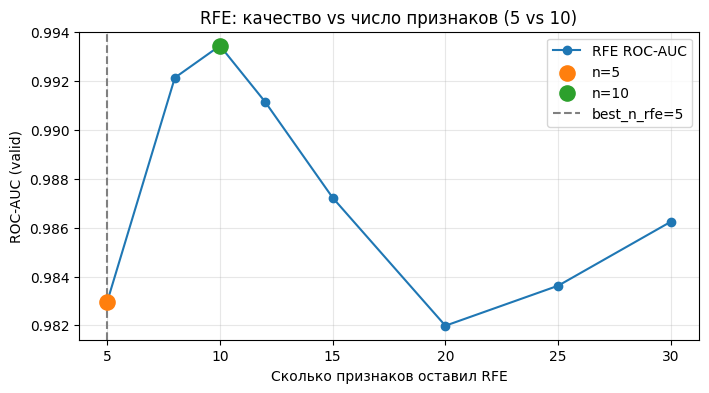

In [91]:
# --- 4.2. best_n_rfe + график ---
# Правило выбора: НЕ «максимальный ROC-AUC», а
# «минимальное n среди тех, где падение AUC vs baseline < 2%».
# Поэтому 5 часто побеждает 10 даже при чуть меньшем AUC.

ok_rfe = rfe_results[rfe_results["auc_drop_pct_vs_baseline"] < 2]
if len(ok_rfe) > 0:
    best_n_rfe = int(ok_rfe["n_features"].min())  # компактность в допуске качества
else:
    # запасной план: тогда уже берём n с лучшим ROC-AUC
    best_n_rfe = int(rfe_results.loc[rfe_results["roc_auc"].idxmax(), "n_features"])

print("Выбрали best_n_rfe =", best_n_rfe)
print("(это min(n) среди ok_rfe, а не argmax ROC-AUC)")
print()

# --- Сравнение n=5 и n=10 из реальной таблицы rfe_results ---
compare_n = rfe_results[rfe_results["n_features"].isin([5, 10])].copy()
if len(compare_n) == 2:
    row5 = compare_n.loc[compare_n["n_features"] == 5].iloc[0]
    row10 = compare_n.loc[compare_n["n_features"] == 10].iloc[0]
    auc5, auc10 = row5["roc_auc"], row10["roc_auc"]
    drop5, drop10 = row5["auc_drop_pct_vs_baseline"], row10["auc_drop_pct_vs_baseline"]

    print("=== Сравнение n=5 и n=10 (valid) ===")
    display(compare_n.round(4))
    print()
    print(f"ROC-AUC при n=5 : {auc5:.4f}  |  падение vs baseline: {drop5:.4f}%")
    print(f"ROC-AUC при n=10: {auc10:.4f}  |  падение vs baseline: {drop10:.4f}%")
    if auc10 > auc5:
        print(f"→ По ROC-AUC лучше n=10 (выше на {auc10 - auc5:.4f}).")
    elif auc5 > auc10:
        print(f"→ По ROC-AUC лучше n=5 (выше на {auc5 - auc10:.4f}).")
    else:
        print("→ ROC-AUC у n=5 и n=10 одинаковый.")

    print()
    print("Проходят ли порог «падение < 2%»?")
    print(f"  n=5  в ok_rfe? {drop5 < 2}")
    print(f"  n=10 в ok_rfe? {drop10 < 2}")
    print()
    if drop5 < 2 and drop10 < 2:
        print("Оба в допуске → код берёт min = 5 (компактность), хотя AUC у 10 может быть выше.")
    elif drop5 < 2:
        print("Только n=5 в допуске → выбор 5 логичен и по качеству, и по компактности.")
    elif drop10 < 2:
        print("n=5 не в допуске, n=10 в допуске → best_n_rfe стал бы 10 (если 10 — минимальное среди ok).")
    else:
        print("Оба не в допуске → сработал бы запасной план (argmax ROC-AUC).")

    # Для наглядности: что выбрали бы, если гнались только за max AUC
    n_max_auc = int(rfe_results.loc[rfe_results["roc_auc"].idxmax(), "n_features"])
    print()
    print(f"Если бы правило было «максимальный ROC-AUC», взяли бы n = {n_max_auc}.")
    print(f"Фактически (правило урока) выбрали n = {best_n_rfe}.")
else:
    print("В rfe_results нет обеих строк n=5 и n=10 — смотрите таблицу rfe_results целиком.")

plt.figure(figsize=(8, 4))
plt.plot(rfe_results["n_features"], rfe_results["roc_auc"], marker="o", label="RFE ROC-AUC")
# Подсветим 5 и 10, если есть
for n_mark, color in [(5, "C1"), (10, "C2")]:
    sub = rfe_results[rfe_results["n_features"] == n_mark]
    if len(sub):
        plt.scatter(sub["n_features"], sub["roc_auc"], s=120, zorder=5,
                    color=color, label=f"n={n_mark}")
plt.axvline(best_n_rfe, linestyle="--", color="gray", label=f"best_n_rfe={best_n_rfe}")
plt.xlabel("Сколько признаков оставил RFE")
plt.ylabel("ROC-AUC (valid)")
plt.title("RFE: качество vs число признаков (5 vs 10)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


In [92]:
# --- 4.3. RFE на test ---
rfe_final = Pipeline([
    ("scaler", StandardScaler()),
    ("rfe", RFE(
        estimator=LogisticRegression(max_iter=3000, solver="liblinear", random_state=RANDOM_STATE),
        n_features_to_select=best_n_rfe,
        step=5
    )),
    ("clf", LogisticRegression(max_iter=3000, solver="liblinear", random_state=RANDOM_STATE))
])

rfe_test = fit_and_eval(rfe_final, X_dev, y_dev, X_test, y_test)
rfe_final.fit(X_dev, y_dev)
selected_rfe_names = X.columns[rfe_final.named_steps["rfe"].get_support()].tolist()
rfe_drop_test = drop_pct(rfe_test["roc_auc"], baseline_test["roc_auc"])

print("Отобранные признаки (RFE):")
print(selected_rfe_names)
print()
print("Падение ROC-AUC на test vs baseline, %:", round(rfe_drop_test, 4))


Отобранные признаки (RFE):
['radius error', 'worst radius', 'worst texture', 'worst perimeter', 'worst concave points']

Падение ROC-AUC на test vs baseline, %: -1.6216


In [93]:
# --- 4.4. Сравним, какие признаки выбрали методы ---
sel = set(selected_k_names)
rfe = set(selected_rfe_names)

print("Общие (выбрали оба):", sorted(sel & rfe))
print("Только SelectKBest:", sorted(sel - rfe))
print("Только RFE:", sorted(rfe - sel))

comparison_fs = pd.DataFrame([
    {"method": "baseline", **baseline_test, "n_features": X.shape[1]},
    {"method": f"SelectKBest k={best_k}", **selectk_test, "n_features": best_k},
    {"method": f"RFE n={best_n_rfe}", **rfe_test, "n_features": best_n_rfe},
])
comparison_fs["auc_drop_pct_vs_baseline"] = drop_pct(
    comparison_fs["roc_auc"], baseline_test["roc_auc"]
)
display(comparison_fs.round(4))


Общие (выбрали оба): ['worst concave points', 'worst perimeter', 'worst radius']
Только SelectKBest: ['mean concave points', 'mean perimeter']
Только RFE: ['radius error', 'worst texture']


,method,roc_auc,f1,fit_sec,n_features,auc_drop_pct_vs_baseline
0,baseline,0.9788,0.9577,0.0102,100,0.0000
1,SelectKBest k=5,0.9914,0.9429,0.0028,5,-1.2838
2,RFE n=5,0.9947,0.9583,0.1013,5,-1.6216


### Короткий вывод по отбору признаков

- Мы **сократили** число колонок и сохранили (или даже улучшили) качество.  
- SelectKBest и RFE могут выбрать **разные** списки — это нормально:  
  - filter смотрит «по одной колонке»,  
  - wrapper смотрит «как колонки работают вместе в модели».


## 5. PCA — сжимаем много колонок в несколько чисел

### Зачем это нужно

У нас ~100 колонок. Многие из них **похожи** или **шумные**.

**SelectKBest / RFE** — *выкидывают* лишние **старые** колонки.  
**PCA** — *не выкидывает*, а **перепаковывает** данные: из 100 чисел делает, например, 5–15 **новых**, стараясь сохранить смысл.

Простая аналогия:
- было 20 фото одной комнаты с разных углов;
- PCA оставляет «самый полезный ракурс», потом «второй по полезности» и т.д.

---

### Дисперсия — одним абзацем

**Дисперсия** = насколько числа **разбросаны**.

- Рост 170, 171, 169 → почти одинаково → **маленькая** дисперсия.  
- Рост 150, 170, 190 → сильно по-разному → **большая** дисперсия.

PCA ищет оси, где разброс **максимальный** (там «больше информации»).

| Ось | Смысл |
|-----|--------|
| **PC1** | направление с самым сильным разбросом |
| **PC2** | следующий по силе разброс (под другим углом) |
| **доля дисперсии** | сколько % всего разброса «держит» эта ось |

**Пример:** PC1 = 50%, PC2 = 30%, PC3 = 15% → вместе 95%.  
Значит, **3 оси** уже описывают почти весь разброс данных.

---

### Важно перед PCA

Сначала **StandardScaler** (все колонки в одном масштабе).  
Иначе колонка «в миллионах» перетянет PCA на себя.

Порядок всегда: **масштабирование → PCA → модель**.

---

### Что сделаем в коде (короткий план)

1. На игрушечных числах посмотрим, как копятся 50% + 30% + …  
2. На train узнаем: **сколько осей нужно**, чтобы набрать 95% разброса.  
3. Переберём разное число осей и посмотрим ROC-AUC (как k у SelectKBest).  
4. Выберем **самое маленькое** число осей, где качество почти как у baseline (падение меньше 2%).  
5. Проверим на test и нарисуем точки в 2D (PC1, PC2).


### Шаг 5.0 — как складываются доли (без реальных данных)

Ниже не обучаем PCA. Просто считаем:  
0.50 + 0.30 = 0.80, + 0.15 = 0.95…  
И находим, с какой компоненты накопленная сумма впервые ≥ 0.95.


In [94]:
# --- 5.0. Игрушечный пример: доли «разброса» ---
# Представим, что PCA уже сказал:
# PC1 держит 50% разброса, PC2 — 30%, PC3 — 15%, PC4 — 5%.
ratios = np.array([0.50, 0.30, 0.15, 0.05])

# Накопительная сумма: сколько % «закрыли» первыми 1, 2, 3, … осями
cum = np.cumsum(ratios)
# cum = [0.50, 0.80, 0.95, 1.00]

print("Доля каждой оси:     ", ratios)
print("Накопили по порядку: ", cum)

# С какой оси впервые набрали 95%?
n95_toy = int(np.searchsorted(cum, 0.95) + 1)
print("Чтобы набрать 95% разброса, достаточно осей:", n95_toy)


Доля каждой оси:      [0.5  0.3  0.15 0.05]
Накопили по порядку:  [0.5  0.8  0.95 1.  ]
Чтобы набрать 95% разброса, достаточно осей: 3


### Шаг 5.1 — на реальных данных: сколько осей для 95%

1. Масштабируем train.  
2. Строим PCA на **всех** возможных осях.  
3. Смотрим доли разброса и находим `n95` — минимум осей с суммой ≥ 95%.  
4. Рисуем кривую: «чем больше осей — тем больше разброса сохранили».


Нужно осей для 95% разброса (n95): 69
Первые 5 долей:       [0.1353 0.0624 0.0302 0.0246 0.0212]
Первые 5 накопленно:  [0.1353 0.1977 0.2278 0.2525 0.2737]


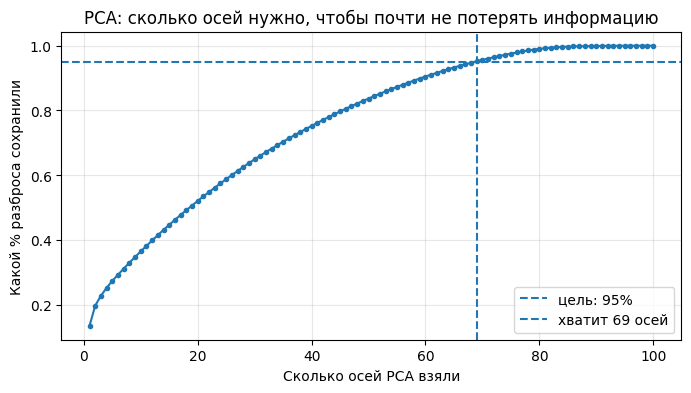

In [95]:
# --- 5.1. Сколько осей нужно, чтобы сохранить 95% разброса ---
# 1) Один масштаб для всех колонок
scaler_pca = StandardScaler()
X_train_scaled = scaler_pca.fit_transform(X_train)

# 2) PCA «смотрит» на данные и раскладывает разброс по осям PC1, PC2, ...
pca_full = PCA(random_state=RANDOM_STATE)
pca_full.fit(X_train_scaled)

# 3) Доля разброса каждой оси и накопленная сумма
shares = pca_full.explained_variance_ratio_   # например 0.12, 0.09, ...
cum_var = np.cumsum(shares)                   # 0.12, 0.21, ...

# 4) Минимальное число осей, чтобы накопить >= 95%
n95 = int(np.searchsorted(cum_var, 0.95) + 1)

print("Нужно осей для 95% разброса (n95):", n95)
print("Первые 5 долей:      ", np.round(shares[:5], 4))
print("Первые 5 накопленно: ", np.round(cum_var[:5], 4))

# График: по горизонтали — число осей, по вертикали — сколько % разброса сохранили
plt.figure(figsize=(8, 4))
plt.plot(np.arange(1, len(cum_var) + 1), cum_var, marker="o", markersize=3)
plt.axhline(0.95, linestyle="--", label="цель: 95%")
plt.axvline(n95, linestyle="--", label=f"хватит {n95} осей")
plt.xlabel("Сколько осей PCA взяли")
plt.ylabel("Какой % разброса сохранили")
plt.title("PCA: сколько осей нужно, чтобы почти не потерять информацию")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


### Шаг 5.2 — подбираем число осей по качеству модели

`n95` говорит про **разброс данных**, но нам важно ещё и **качество предсказания**.

Поэтому, как с k в SelectKBest:
- пробуем 2, 3, 5, … осей (и `n95`);
- для каждого варианта: масштабирование → PCA → логистическая регрессия;
- смотрим ROC-AUC на valid и падение относительно baseline.


In [96]:
# --- 5.2. Перебор: 2, 3, 5, ... осей + n95 ---
comp_grid = sorted(set([2, 3, 5, 8, 10, 12, 15, 20, 25, 30, n95]))
comp_grid = [c for c in comp_grid if c <= X.shape[1]]  # не больше числа колонок

rows = []
for n_comp in comp_grid:
    # Одинаковая модель, разное только число осей PCA
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("pca", PCA(n_components=n_comp, random_state=RANDOM_STATE)),
        ("clf", LogisticRegression(
            max_iter=3000, solver="liblinear", random_state=RANDOM_STATE
        )),
    ])
    m = fit_and_eval(pipe, X_train, y_train, X_valid, y_valid)
    rows.append({"n_components": n_comp, **m})

pca_results = pd.DataFrame(rows).sort_values("n_components").reset_index(drop=True)

# На сколько % хуже/лучше baseline (как раньше)
pca_results["auc_drop_pct_vs_baseline"] = drop_pct(
    pca_results["roc_auc"], baseline_valid["roc_auc"]
)

print("Смотрите auc_drop_pct_vs_baseline: хотим меньше 2 (лучше — отрицательное).")
display(pca_results.round(4))


Смотрите auc_drop_pct_vs_baseline: хотим меньше 2 (лучше — отрицательное).


,n_components,roc_auc,f1,fit_sec,auc_drop_pct_vs_baseline
0,2,0.9856,0.9571,0.0348,0.0332
1,3,0.9876,0.9504,0.0082,-0.1661
2,5,0.9938,0.9790,0.0141,-0.7973
3,8,0.9951,0.9859,0.0087,-0.9302
4,10,0.9908,0.9718,0.0147,-0.4983
5,12,0.9941,0.9790,0.0130,-0.8306
6,15,0.9944,0.9790,0.0135,-0.8638
7,20,0.9934,0.9655,0.0104,-0.7641
8,25,0.9885,0.9722,0.0068,-0.2658
9,30,0.9846,0.9583,0.0086,0.1329


### Шаг 5.3 — выбираем best_n_pca

То же правило, что у SelectKBest / RFE:

1. Оставляем варианты с падением AUC **меньше 2%**.  
2. Среди них берём **самое маленькое** число осей (компактность).  
3. Если никто не прошёл — берём вариант с лучшим ROC-AUC.


Выбрали best_n_pca = 2
(минимум осей при падении AUC < 2% vs baseline)


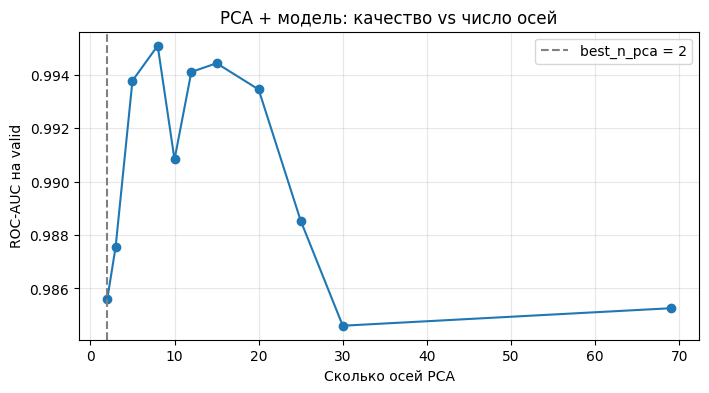

In [97]:
# --- 5.3. Выбираем best_n_pca ---
ok_pca = pca_results[pca_results["auc_drop_pct_vs_baseline"] < 2]

if len(ok_pca) > 0:
    # самое маленькое число осей в «зелёной зоне»
    best_n_pca = int(ok_pca["n_components"].min())
else:
    # запасной план: лучший ROC-AUC
    best_n_pca = int(pca_results.loc[pca_results["roc_auc"].idxmax(), "n_components"])

print("Выбрали best_n_pca =", best_n_pca)
print("(минимум осей при падении AUC < 2% vs baseline)")

plt.figure(figsize=(8, 4))
plt.plot(pca_results["n_components"], pca_results["roc_auc"], marker="o")
plt.axvline(best_n_pca, linestyle="--", color="gray", label=f"best_n_pca = {best_n_pca}")
plt.xlabel("Сколько осей PCA")
plt.ylabel("ROC-AUC на valid")
plt.title("PCA + модель: качество vs число осей")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


### Шаг 5.4 — финал на test

Учим на dev (train+valid), проверяем на test — как «экзамен».  
Сравниваем с baseline (все колонки без PCA).


In [98]:
# --- 5.4. PCA на test ---
pca_final = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=best_n_pca, random_state=RANDOM_STATE)),
    ("clf", LogisticRegression(
        max_iter=3000, solver="liblinear", random_state=RANDOM_STATE
    )),
])

pca_test = fit_and_eval(pca_final, X_dev, y_dev, X_test, y_test)
pca_drop_test = drop_pct(pca_test["roc_auc"], baseline_test["roc_auc"])

summary_pca = pd.DataFrame([
    {"method": "baseline (все колонки)", **baseline_test, "dim": X.shape[1]},
    {"method": f"PCA ({best_n_pca} осей)", **pca_test, "dim": best_n_pca},
])
summary_pca["auc_drop_pct_vs_baseline"] = drop_pct(
    summary_pca["roc_auc"], baseline_test["roc_auc"]
)

print("Падение ROC-AUC vs baseline на test, %:", round(pca_drop_test, 4))
print("(отрицательное = PCA даже лучше baseline)")
display(summary_pca.round(4))


Падение ROC-AUC vs baseline на test, %: -0.8446
(отрицательное = PCA даже лучше baseline)


,method,roc_auc,f1,fit_sec,dim,auc_drop_pct_vs_baseline
0,baseline (все колонки),0.9788,0.9577,0.0102,100,0.0000
1,PCA (2 осей),0.9871,0.9437,0.0200,2,-0.8446


### Шаг 5.5 — картинка в 2D

Берём только **2** оси (PC1, PC2), чтобы нарисовать точки на плоскости.  
Цвет = класс 0 или 1.

- Если цвета **разъехались** по PC1 — сжатие удачное.  
- Если цвета **перемешаны** — в 2D разделить сложно (в модели осей может быть больше двух).


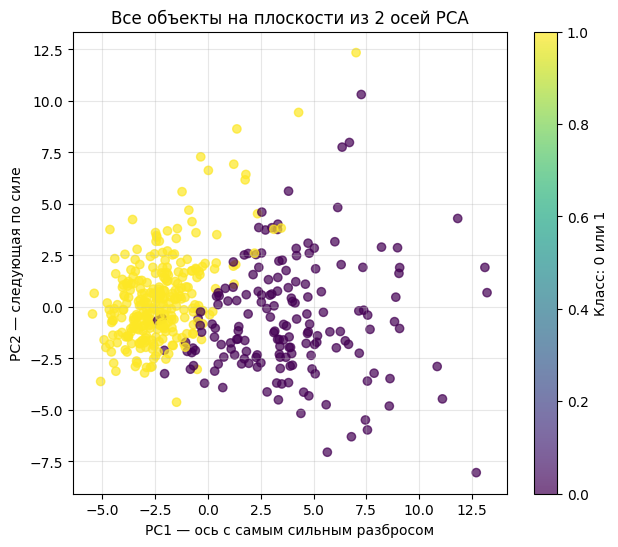

In [99]:
# --- 5.5. Рисуем данные на двух осях PCA ---
pca_2d = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=2, random_state=RANDOM_STATE)),
])
# Каждая строка данных → 2 числа: (PC1, PC2)
X_dev_2d = pca_2d.fit_transform(X_dev)

plt.figure(figsize=(7, 6))
sc = plt.scatter(X_dev_2d[:, 0], X_dev_2d[:, 1], c=y_dev, alpha=0.7)
plt.xlabel("PC1 — ось с самым сильным разбросом")
plt.ylabel("PC2 — следующая по силе")
plt.title("Все объекты на плоскости из 2 осей PCA")
plt.colorbar(sc, label="Класс: 0 или 1")
plt.grid(alpha=0.3)
plt.show()


### Короткий вывод по PCA

| Вопрос | Ответ |
|--------|--------|
| PCA выкидывает старые колонки? | Нет, делает **новые** оси |
| Зачем дисперсия? | Показывает, где в данных больше разброса / «информации» |
| Сколько осей брать? | Сначала смотрим 95% разброса, потом — качество модели |
| Правило выбора | Как у FS: **минимум осей** при падении AUC меньше 2% |
| Минус PCA | Новые оси **сложнее объяснить** словами, чем «температура» или «размер» |


## 6. Итог: сравниваем все методы

Смотрим на три вопроса:

1. **Насколько сжали?** (было 100 колонок → стало k / n / компоненты)  
2. **Не испортили ли качество?** (падение ROC-AUC на test < 2%)  
3. **Что удобнее читать человеку?**  
   - SelectKBest / RFE → список **старых** имён колонок  
   - PCA → **новые** оси (интерпретировать сложнее)


In [100]:
# --- 6. Итоговая таблица ---
result_checks = pd.DataFrame([
    {
        "method": "SelectKBest",
        "dim_before": X.shape[1],
        "dim_after": best_k,
        "auc_drop_pct_test": selectk_drop_test,
        "ok_under_2pct": selectk_drop_test < 2
    },
    {
        "method": "RFE",
        "dim_before": X.shape[1],
        "dim_after": best_n_rfe,
        "auc_drop_pct_test": rfe_drop_test,
        "ok_under_2pct": rfe_drop_test < 2
    },
    {
        "method": "PCA",
        "dim_before": X.shape[1],
        "dim_after": best_n_pca,
        "auc_drop_pct_test": pca_drop_test,
        "ok_under_2pct": pca_drop_test < 2
    },
])

display(result_checks.round(4))

print()
print("=== Как читать таблицу ===")
print("dim_before / dim_after — сколько колонок (или компонент) было и стало.")
print("auc_drop_pct_test — % изменения ROC-AUC vs baseline (минус = лучше).")
print("ok_under_2pct — уложились ли в правило «просадка < 2%».")


,method,dim_before,dim_after,auc_drop_pct_test,ok_under_2pct
0,SelectKBest,100,5,-1.2838,True
1,RFE,100,5,-1.6216,True
2,PCA,100,2,-0.8446,True



=== Как читать таблицу ===
dim_before / dim_after — сколько колонок (или компонент) было и стало.
auc_drop_pct_test — % изменения ROC-AUC vs baseline (минус = лучше).
ok_under_2pct — уложились ли в правило «просадка < 2%».


## Выводы простыми словами

1. **Baseline** нужен, чтобы было с чем сравнивать.  
2. **SelectKBest** — быстрый способ оставить top‑k полезных колонок.  
3. **RFE** — медленнее, но отбор «под модель»; набор признаков может отличаться.  
4. **PCA** — не отбор, а **сжатие** в новые оси; удобно, когда колонок очень много.  
5. Практическое правило урока: уменьшаем размерность, пока падение ROC-AUC **< 2%** (а часто качество даже растёт, потому что уходит шум).

---

### Словарь «на холодильник»

| Термин | Простыми словами |
|--------|------------------|
| Признак | колонка-подсказка |
| Target | то, что предсказываем |
| Train / Valid / Test | учёба / пробник / экзамен |
| Baseline | модель «на всём» |
| Feature selection | выкинуть лишние колонки |
| PCA | сжать колонки в новые оси |
| ROC-AUC | качество ранжирования 0/1 |
